# High-Water 🏔️
### "Buy stocks near their 52-week high" — a distinct edge, or just momentum?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A distinct anomaly?: Busted](https://img.shields.io/badge/A_distinct_anomaly%3F-Busted-8b949e?style=flat-square)

There's a famous idea that stocks trading near their one-year high keep climbing — an *anchoring* story said to be different from plain momentum. We test both halves on large-cap stocks: it didn't pay (the long-short *lost*), and it turns out to be 0.87 correlated with ordinary momentum — the same factor with a behavioural label.

> 📓 **Plain-language layer.** The correlation and the t-stats are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (high_water/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from high_water import data, strategy as st
ret = data.fetch_panel()                       # cache-first; built by examples/verify.py --fetch
hi = st.cross_section_hedge(ret, st.nearness(ret))
mo = st.cross_section_hedge(ret, st.momentum(ret))


## The answer first 🎯

| The claim | The data (2000–2026, large caps) |
|---|---|
| "Near-high stocks out-earn" | The long-short earns **−8.4%/yr** (Sharpe −0.40) — it *lost*. |
| "It's distinct from momentum" | It's **0.87 correlated** with the momentum hedge. |
| "A free anchoring edge" | Negative gross, so costs only deepen the hole. |

## 1 · The claim

George & Hwang (2004): a stock's **nearness to its 52-week high** (price ÷ one-year high) predicts its return — investors anchor on the high and underreact — and this beats, and is *separate from*, Jegadeesh-Titman momentum.

## 2 · So what?

If it's a distinct, durable edge, it's another factor for the toolbox. If it's momentum relabelled — and momentum that didn't even pay on large caps — then it's a story dressed as a discovery.

## 3 · How would we even know?

Build the nearness long-short, measure its return and t-stat, then **correlate it with a plain 12-month-momentum long-short**. High correlation means same factor; a negative return means no premium to begin with.

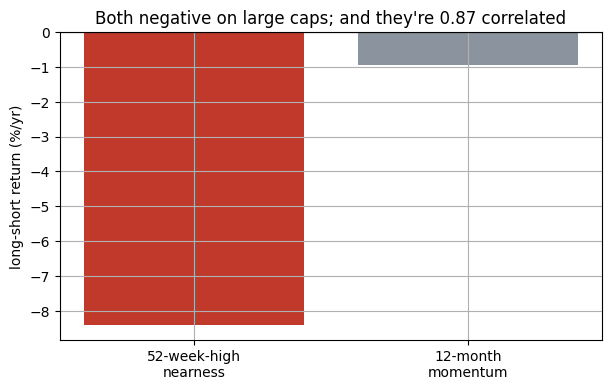

In [2]:
h,m=st.stats(hi),st.stats(mo)
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['52-week-high\nnearness','12-month\nmomentum'],[h['mean_ann']*100,m['mean_ann']*100],color=['#c0392b','#8b949e'])
ax.set_ylabel('long-short return (%/yr)'); ax.axhline(0,color='k',lw=.8)
ax.set_title(f"Both negative on large caps; and they're {st.signal_overlap(ret):.2f} correlated"); plt.show()

## 4 · The teardown

The two hedges move together — because they *are* the same bet. And near-high names got punished in the 2000 and 2008 rebounds.

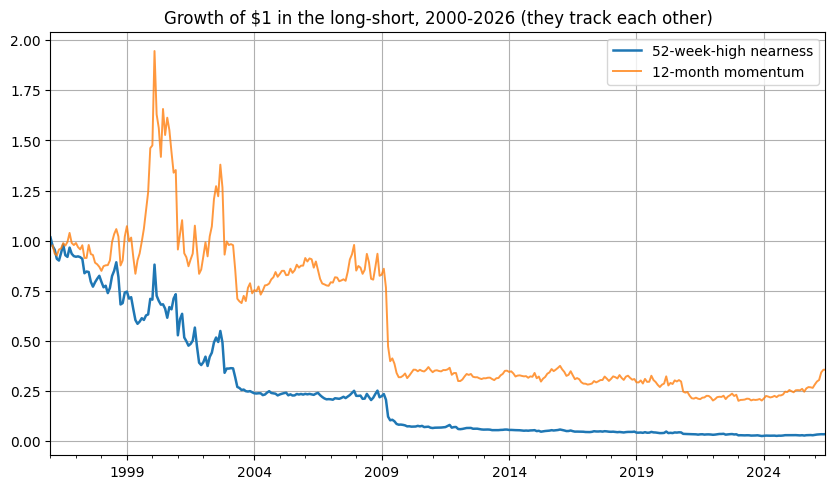

correlation of the two hedges: +0.87


In [3]:
eqH=(1+hi).cumprod(); eqM=(1+mo).cumprod()
ax=eqH.plot(label='52-week-high nearness',lw=1.8); eqM.plot(ax=ax,label='12-month momentum',lw=1.4,alpha=.8)
ax.set_title('Growth of $1 in the long-short, 2000-2026 (they track each other)'); ax.legend(); plt.show()
print(f"correlation of the two hedges: {st.signal_overlap(ret):+.2f}")

**Read it plainly.** Two lines on top of each other, both heading down. The 52-week-high signal isn't a new edge — it's momentum, and momentum didn't pay on this universe.

## 5 · The verdict

**Signal: None** — the long-short lost (significantly). **Tradability: Mirage** — negative gross. **A distinct anomaly?: Busted** — 0.87 correlated with momentum.

## 6 · Could you actually trade it?

There's nothing to trade: the gross hedge is negative, and to the extent it captures anything, it's the momentum factor you could get more cleanly (and which also struggled here — see [Study 24 Stampede](../../24-stampede/)).

## 7 · Going further 🚪

The quants notebook shows the 0.87 correlation and the decay. This closes the second five-study bench (46–50). The negative sign ties to [Study 33 Slingshot](../../33-slingshot/) — reversal on the S&P cross-section.